In [1]:
!pip install opencv-python

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

KeyboardInterrupt: 

In [ ]:
dataset_path = r"C:\Users\HP-pc\Downloads\archive\real_and_fake_face"

In [ ]:
real_path = os.path.join(dataset_path, "training_real")
fake_path = os.path.join(dataset_path, "training_fake")

real_images = os.listdir(real_path)
fake_images = os.listdir(fake_path)

print("Number of real images:", len(real_images))
print("Number of fake images:", len(fake_images))

In [ ]:
plt.figure(figsize=(10,5))

real_img = cv2.imread(os.path.join(real_path, real_images[0]))
real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real Face")
plt.axis("off")

fake_img = cv2.imread(os.path.join(fake_path, fake_images[0]))
fake_img = cv2.cvtColor(fake_img, cv2.COLORBGR2RGB)

plt.subplot(1,2,2)
plt.imshow(fake_img)
plt.title("fake face")
plt.axis("off")

plt.show()

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [19]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1633 images belonging to 2 classes.
Found 408 images belonging to 2 classes.


In [20]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(1, activation='sigmoid'))

C:\Users\HP-pc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4887 - loss: 0.7188 - val_accuracy: 0.5123 - val_loss: 0.6931
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.5193 - loss: 0.6936 - val_accuracy: 0.5196 - val_loss: 0.6923
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5579 - loss: 0.6864 - val_accuracy: 0.5147 - val_loss: 0.6939
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.5713 - loss: 0.6774 - val_accuracy: 0.5417 - val_loss: 0.7010
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6118 - loss: 0.6717 - val_accuracy: 0.5049 - val_loss: 0.7029
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6277 - loss: 0.6550 - val_accuracy: 0.5147 - val_loss: 0.7240
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6369 - loss: 0.6392 - val_accuracy: 0.5147 - val_loss: 0.7875
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6448 - loss: 0.6335 - val_accuracy: 0.5319 - val_l

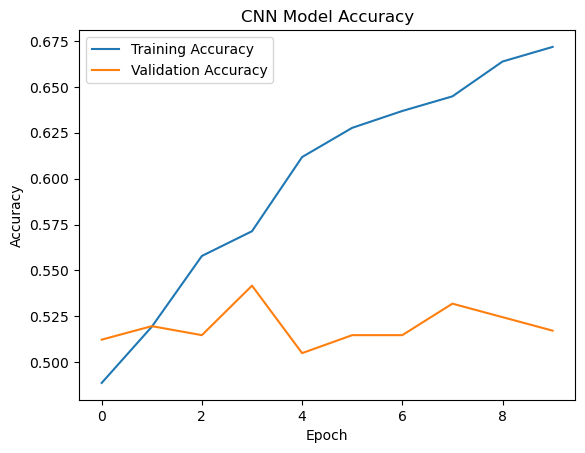

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

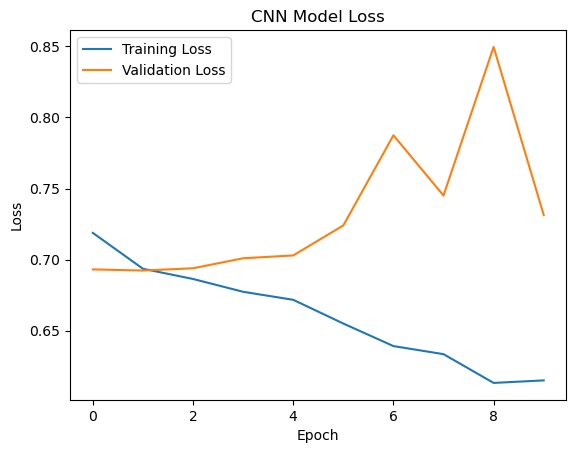

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [25]:
loss, accuracy = cnn_model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5172 - loss: 0.7314
Validation Loss: 0.731394350528717
Validation Accuracy: 0.5171568393707275


In [29]:
predictions = cnn_model.predict(val_data)
predictions = (predictions > 0.5)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


In [30]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(
    val_data.classes,
    predictions
))

              precision    recall  f1-score   support

           0       0.47      0.40      0.43       192
           1       0.53      0.60      0.56       216

    accuracy                           0.51       408
   macro avg       0.50      0.50      0.50       408
weighted avg       0.50      0.51      0.50       408



In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
cm = confusion_matrix(
    val_data.classes,
    predictions
)

print(cm)

[[ 77 115]
 [ 86 130]]


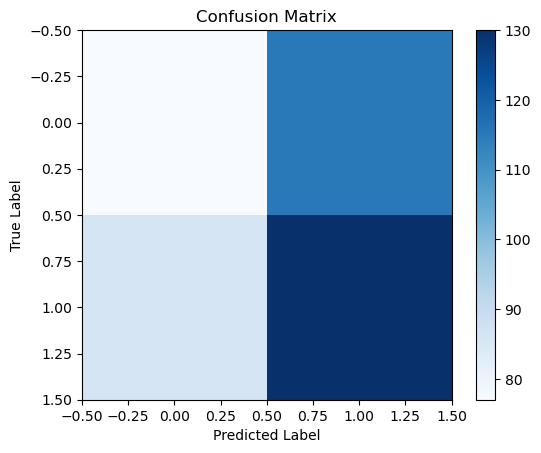

In [33]:
plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.colorbar()

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

[[ 77 115]
 [ 86 130]]


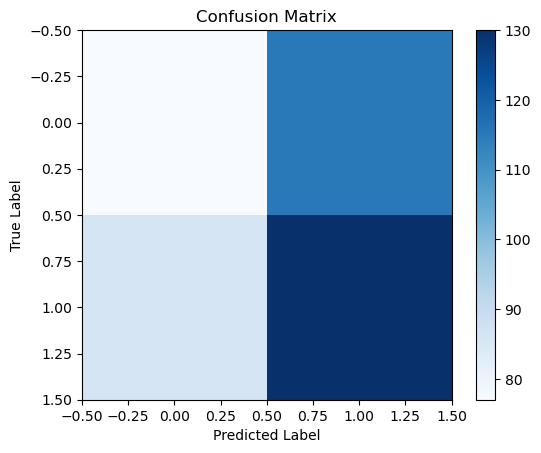

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    val_data.classes,
    predictions
)

print(cm)

plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.colorbar()

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [38]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

In [39]:
mobilenet_model = Sequential()

mobilenet_model.add(base_model)

mobilenet_model.add(GlobalAveragePooling2D())

mobilenet_model.add(Dense(128, activation='relu'))

mobilenet_model.add(Dense(1, activation='sigmoid'))

In [40]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.5848 - loss: 0.7182 - val_accuracy: 0.5245 - val_loss: 0.7417
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6687 - loss: 0.6149 - val_accuracy: 0.5098 - val_loss: 0.7659
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7226 - loss: 0.5502 - val_accuracy: 0.5343 - val_loss: 0.8142
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7832 - loss: 0.4894 - val_accuracy: 0.5441 - val_loss: 0.9306
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7967 - loss: 0.4475 - val_accuracy: 0.5417 - val_loss: 0.8807
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8304 - loss: 0.3854 - val_accuracy: 0.5417 - val_loss: 0.8691
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8579 - loss: 0.3406 - val_accuracy: 0.5392 - val_loss: 1.0378
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9045 - loss: 0.2745 - val_accuracy: 0.5319 - val_loss

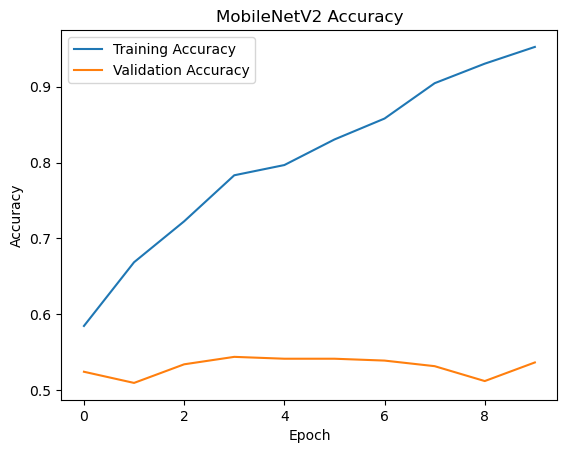

In [42]:
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

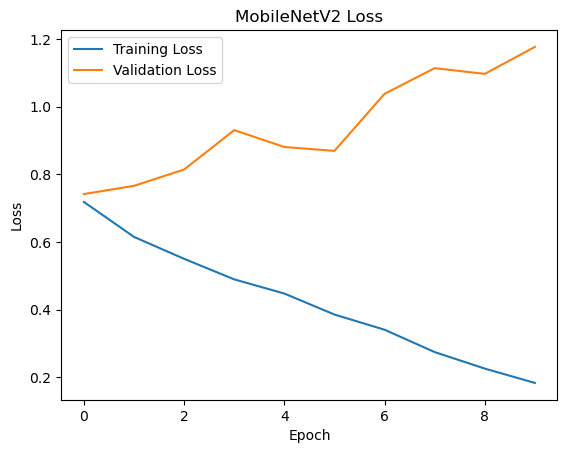

In [43]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [44]:
loss_mobilenet, accuracy_mobilenet = mobilenet_model.evaluate(val_data)

print("MobileNetV2 Validation Loss:", loss_mobilenet)
print("MobileNetV2 Validation Accuracy:", accuracy_mobilenet)

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5368 - loss: 1.1766
MobileNetV2 Validation Loss: 1.1765587329864502
MobileNetV2 Validation Accuracy: 0.5367646813392639


In [45]:
predictions_mobilenet = mobilenet_model.predict(val_data)

predictions_mobilenet = (predictions_mobilenet > 0.5)

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    val_data.classes,
    predictions_mobilenet
))

              precision    recall  f1-score   support

           0       0.46      0.30      0.36       192
           1       0.52      0.69      0.59       216

    accuracy                           0.50       408
   macro avg       0.49      0.49      0.48       408
weighted avg       0.49      0.50      0.48       408



[[ 57 135]
 [ 68 148]]


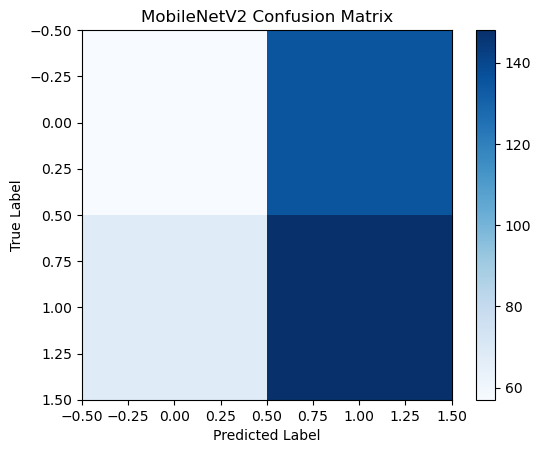

In [47]:
from sklearn.metrics import confusion_matrix

cm_mobilenet = confusion_matrix(
    val_data.classes,
    predictions_mobilenet
)

print(cm_mobilenet)

plt.imshow(cm_mobilenet, cmap='Blues')

plt.title('MobileNetV2 Confusion Matrix')
plt.colorbar()

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()